# Data Analysis For All Weather Stations From IMS

In [22]:
import pandas as pd
from pathlib import Path
from weather_engine import utils as ut

def get_missingness_report(df: pd.DataFrame, file_path: Path):
    """
    Calculates missingness percentage for specific features and returns a summary row.
    """
    feature_cols = df.columns.tolist()
    
    station_name = Path(file_path).stem.split("2020-2026")[0]

    if not df.empty:
        station_id = df['station_id'].iloc[0]
    else:
        station_id = 'Unknown'

    report = {
        'station_name': station_name,
        'station_id': station_id
    }
    
    for col in feature_cols:
        if df.empty:
            report[f"{col}_missingness"] = 100.0
        else:
            missing_pct = (df[col].isna().sum() / len(df)) * 100
            report[f"{col}_missingness"] = round(missing_pct, 2)
            
    return report


data_dir =  ut.get_project_root() / 'data/'
csv_files = list(data_dir.glob('*.csv'))

missingness_results = []
coords_list = []

print(f"Found {len(csv_files)} files. Starting cyclic processing...")

for file_path in csv_files:
    current_df = pd.read_csv(file_path)
    
    station_report = get_missingness_report(current_df, file_path)
    missingness_results.append(station_report)

    if not current_df.empty and 'latitude' in current_df.columns:
        first_valid = current_df[['station_id', 'latitude', 'longitude']].dropna().iloc[:1]
        if not first_valid.empty:
            coords_list.append(first_valid.iloc[0].to_dict())
    
    del current_df

final_report_df = pd.DataFrame(missingness_results)
station_coords_df = pd.DataFrame(coords_list).astype({'station_id': str})

missingness_cols = [c for c in final_report_df.columns if c.endswith('_missingness')]

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    styled_df = final_report_df.style.background_gradient(
        cmap='RdYlGn_r', 
        subset=missingness_cols, 
        vmin=0, 
        vmax=100
    )
    
    display(styled_df)

Found 89 files. Starting cyclic processing...


,station_name,station_id,timestamp_missingness,station_id_missingness,latitude_missingness,longitude_missingness,elevation_missingness,rain_missingness,wsmax_missingness,wdmax_missingness,ws_missingness,wd_missingness,stdwd_missingness,td_missingness,rh_missingness,tdmax_missingness,tdmin_missingness,ws1mm_missingness,ws10mm_missingness
0,MEROM_GOLAN_PICMAN_,10,0.000000,0.000000,0.000000,0.000000,100.000000,0.140000,0.020000,0.020000,0.020000,0.030000,0.020000,0.020000,0.020000,0.020000,0.020000,0.020000,0.020000
1,KEFAR_BLUM_,202,0.000000,0.000000,0.000000,0.000000,100.000000,9.410000,0.010000,0.050000,0.010000,0.050000,0.050000,0.020000,0.060000,0.030000,0.020000,0.010000,0.010000
2,NETIV_HALAMED_HE_,25,0.000000,0.000000,0.000000,0.000000,100.000000,0.270000,0.370000,0.360000,0.370000,0.360000,0.340000,0.060000,0.030000,0.070000,0.100000,0.370000,0.370000
3,HAR_HARASHA_,24,0.000000,0.000000,0.000000,0.000000,100.000000,1.780000,0.030000,0.090000,0.160000,0.090000,0.020000,0.020000,0.020000,0.020000,0.070000,0.020000,0.020000
4,GAT_,236,0.000000,0.000000,0.000000,0.000000,100.000000,3.500000,100.000000,100.000000,100.000000,100.000000,100.000000,0.030000,0.050000,0.040000,0.020000,100.000000,100.000000
5,NEGBA_,82,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.030000,0.380000,0.030000,0.380000,0.380000,0.050000,0.050000,0.030000,0.030000,0.030000,0.030000
6,DOROT_,79,0.000000,0.000000,0.000000,0.000000,100.000000,0.890000,0.020000,0.030000,0.120000,0.030000,0.020000,0.050000,0.070000,0.050000,0.040000,0.020000,41.130000
7,EN_HAHORESH_,107,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000,0.020000,0.020000,0.020000,0.020000,100.000000,100.000000
8,MIZPE_MIDRAG_,504,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
9,YOTVATA_,36,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.020000,0.020000,0.020000,0.020000,0.020000,0.030000,0.020000,0.030000,0.030000,0.020000,17.780000


## Filtering out problematic stations that miss alot of sensors

In [23]:
cols_to_ignore = ['elevation_missingness', 
                    'ws1mm_missingness', 'ws10mm_missingness',
                    'timestamp_missingness', 'station_id_missingness', 
                    'latitude_missingness', 'longitude_missingness']

cols_to_check = [c for c in final_report_df.columns 
                 if c.endswith('_missingness') 
                 and c not in cols_to_ignore]

print(cols_to_check)

stations_to_leave = []

for idx, row in final_report_df.iterrows():
    for col in cols_to_check:
        if row[col] >= 30.0:
            stations_to_leave.append(row['station_id'])
            break

df_bad_stations = final_report_df[final_report_df['station_id'].isin(stations_to_leave)]
print(len(df_bad_stations))
df_bad_stations
            

['rain_missingness', 'wsmax_missingness', 'wdmax_missingness', 'ws_missingness', 'wd_missingness', 'stdwd_missingness', 'td_missingness', 'rh_missingness', 'tdmax_missingness', 'tdmin_missingness']
23


,station_name,station_id,timestamp_missingness,station_id_missingness,latitude_missingness,longitude_missingness,elevation_missingness,rain_missingness,wsmax_missingness,wdmax_missingness,ws_missingness,wd_missingness,stdwd_missingness,td_missingness,rh_missingness,tdmax_missingness,tdmin_missingness,ws1mm_missingness,ws10mm_missingness
4,GAT_,236,0.0,0.0,0.0,0.0,100.0,3.50,100.00,100.00,100.00,100.00,100.00,0.03,0.05,0.04,0.02,100.00,100.00
7,EN_HAHORESH_,107,0.0,0.0,0.0,0.0,100.0,0.00,100.00,100.00,100.00,100.00,100.00,0.02,0.02,0.02,0.02,100.00,100.00
8,MIZPE_MIDRAG_,504,0.0,0.0,0.0,0.0,100.0,0.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
21,HAKFAR_HAYAROK_,275,0.0,0.0,0.0,0.0,100.0,5.74,100.00,100.00,100.00,100.00,100.00,1.09,1.13,100.00,100.00,100.00,100.00
25,NEWE_ZOHAR_UNI_,32,0.0,0.0,0.0,0.0,100.0,100.00,100.00,100.00,100.00,100.00,100.00,0.18,0.17,100.00,100.00,100.00,100.00
27,AMMIAD_,123,0.0,0.0,0.0,0.0,100.0,0.00,100.00,100.00,100.00,100.00,100.00,1.93,1.93,1.93,1.93,100.00,100.00
30,BET_DAGAN_RAD_,85,0.0,0.0,0.0,0.0,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
33,MASSADA_,355,0.0,0.0,0.0,0.0,100.0,0.06,100.00,100.00,100.00,100.00,100.00,0.02,0.02,0.02,0.02,100.00,100.00
35,QEVUZAT_YAVNE_,74,0.0,0.0,0.0,0.0,100.0,0.11,100.00,100.00,100.00,100.00,100.00,0.02,0.02,0.02,0.02,100.00,100.00
41,DEIR_HANNA_,99,0.0,0.0,0.0,0.0,100.0,0.44,100.00,100.00,100.00,100.00,100.00,0.02,0.01,0.02,0.02,100.00,100.00


In [24]:
# How many stations have ANY column over 30%?
print(f"Total stations: {len(final_report_df)}")
print(f"Stations with 30%+ missingness in any column: {len(stations_to_leave)}")

# Which columns are causing the most flags?
for col in cols_to_check:
    over_30 = (final_report_df[col] >= 30.0).sum()
    if over_30 > 0:
        print(f"{col}: {over_30} stations over 30%")

Total stations: 89
Stations with 30%+ missingness in any column: 23
rain_missingness: 5 stations over 30%
wsmax_missingness: 22 stations over 30%
wdmax_missingness: 22 stations over 30%
ws_missingness: 22 stations over 30%
wd_missingness: 22 stations over 30%
stdwd_missingness: 22 stations over 30%
td_missingness: 4 stations over 30%
rh_missingness: 4 stations over 30%
tdmax_missingness: 6 stations over 30%
tdmin_missingness: 6 stations over 30%


In [25]:
df_survived_stations = final_report_df[~final_report_df['station_id'].isin(df_bad_stations['station_id'])]
print(len(df_survived_stations))

66


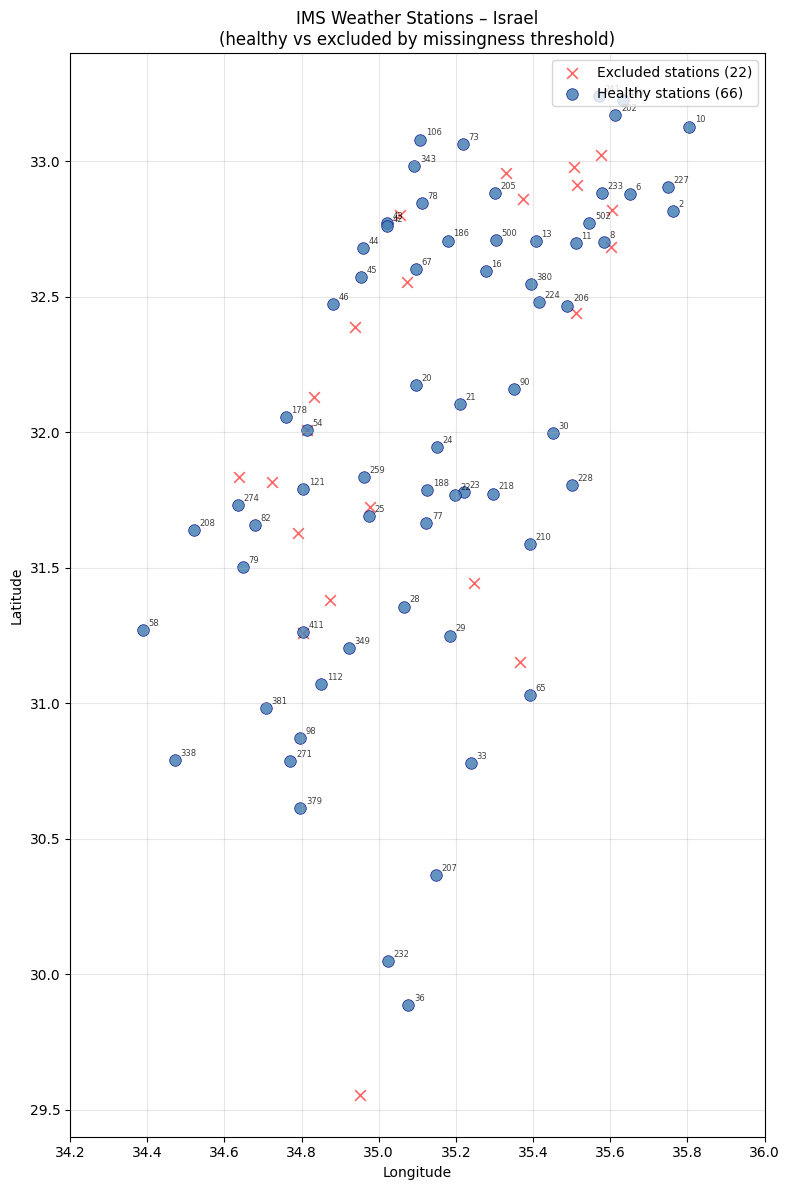

Healthy: 66  |  Excluded: 22


In [33]:
%matplotlib inline
import matplotlib.pyplot as plt

coords = station_coords_df.copy()
coords['station_id'] = coords['station_id'].astype(float).astype(int).astype(str)

healthy_ids = set(df_survived_stations['station_id'].astype(str))
bad_ids = set(df_bad_stations['station_id'].astype(str))

healthy_coords = coords[coords['station_id'].isin(healthy_ids)]
bad_coords = coords[coords['station_id'].isin(bad_ids)]

fig, ax = plt.subplots(figsize=(8, 12))
ax.set_xlim(34.2, 36.0)
ax.set_ylim(29.4, 33.4)

ax.scatter(bad_coords['longitude'], bad_coords['latitude'],
           c='red', alpha=0.6, s=60, marker='x', linewidths=1.2,
           label=f'Excluded stations ({len(bad_coords)})')

ax.scatter(healthy_coords['longitude'], healthy_coords['latitude'],
           c='steelblue', alpha=0.85, s=70, edgecolors='navy', linewidths=0.5,
           label=f'Healthy stations ({len(healthy_coords)})')

for _, row in healthy_coords.iterrows():
    ax.annotate(row['station_id'],
                xy=(row['longitude'], row['latitude']),
                xytext=(4, 3), textcoords='offset points',
                fontsize=6, alpha=0.75)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('IMS Weather Stations – Israel\n(healthy vs excluded by missingness threshold)', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Healthy: {len(healthy_coords)}  |  Excluded: {len(bad_coords)}")